In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type1_df = pd.read_csv('/Users/jisoyun/Desktop/sparta_python/심화 프로젝트/hotsix/data/df_clean_Type1.csv')
type1_df.columns = type1_df.columns.str.strip()

In [2]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Diff',
       'Defect_Status', 'Defect_Type'],
      dtype='str')

In [3]:
cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
type1_df['Velocity_minmax'] = type1_df[cols].max(axis=1) - type1_df[cols].min(axis=1)

In [4]:
display(type1_df[['Velocity_minmax']].head()) 
display(type1_df[['Velocity_minmax']].tail())

,Velocity_minmax
0,1.990
1,1.980
2,1.972
3,1.993
4,1.967


,Velocity_minmax
2646,2.0525
2647,2.0525
2648,2.0525
2649,2.0525
2650,2.0525


In [5]:
type1_df['Velocity_diff_1_2'] = type1_df['Velocity_2'] - type1_df['Velocity_1']
type1_df['Velocity_diff_2_3'] = type1_df['Velocity_3'] - type1_df['Velocity_2']
type1_df['Velocity_diff_3_high'] = type1_df['High_Velocity'] - type1_df['Velocity_3']
type1_df['Pressure_Diff_ratio'] = type1_df['Pressure_Diff'] / type1_df['Cylinder_Pressure']


In [6]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Diff',
       'Defect_Status', 'Defect_Type', 'Velocity_minmax', 'Velocity_diff_1_2',
       'Velocity_diff_2_3', 'Velocity_diff_3_high', 'Pressure_Diff_ratio'],
      dtype='str')

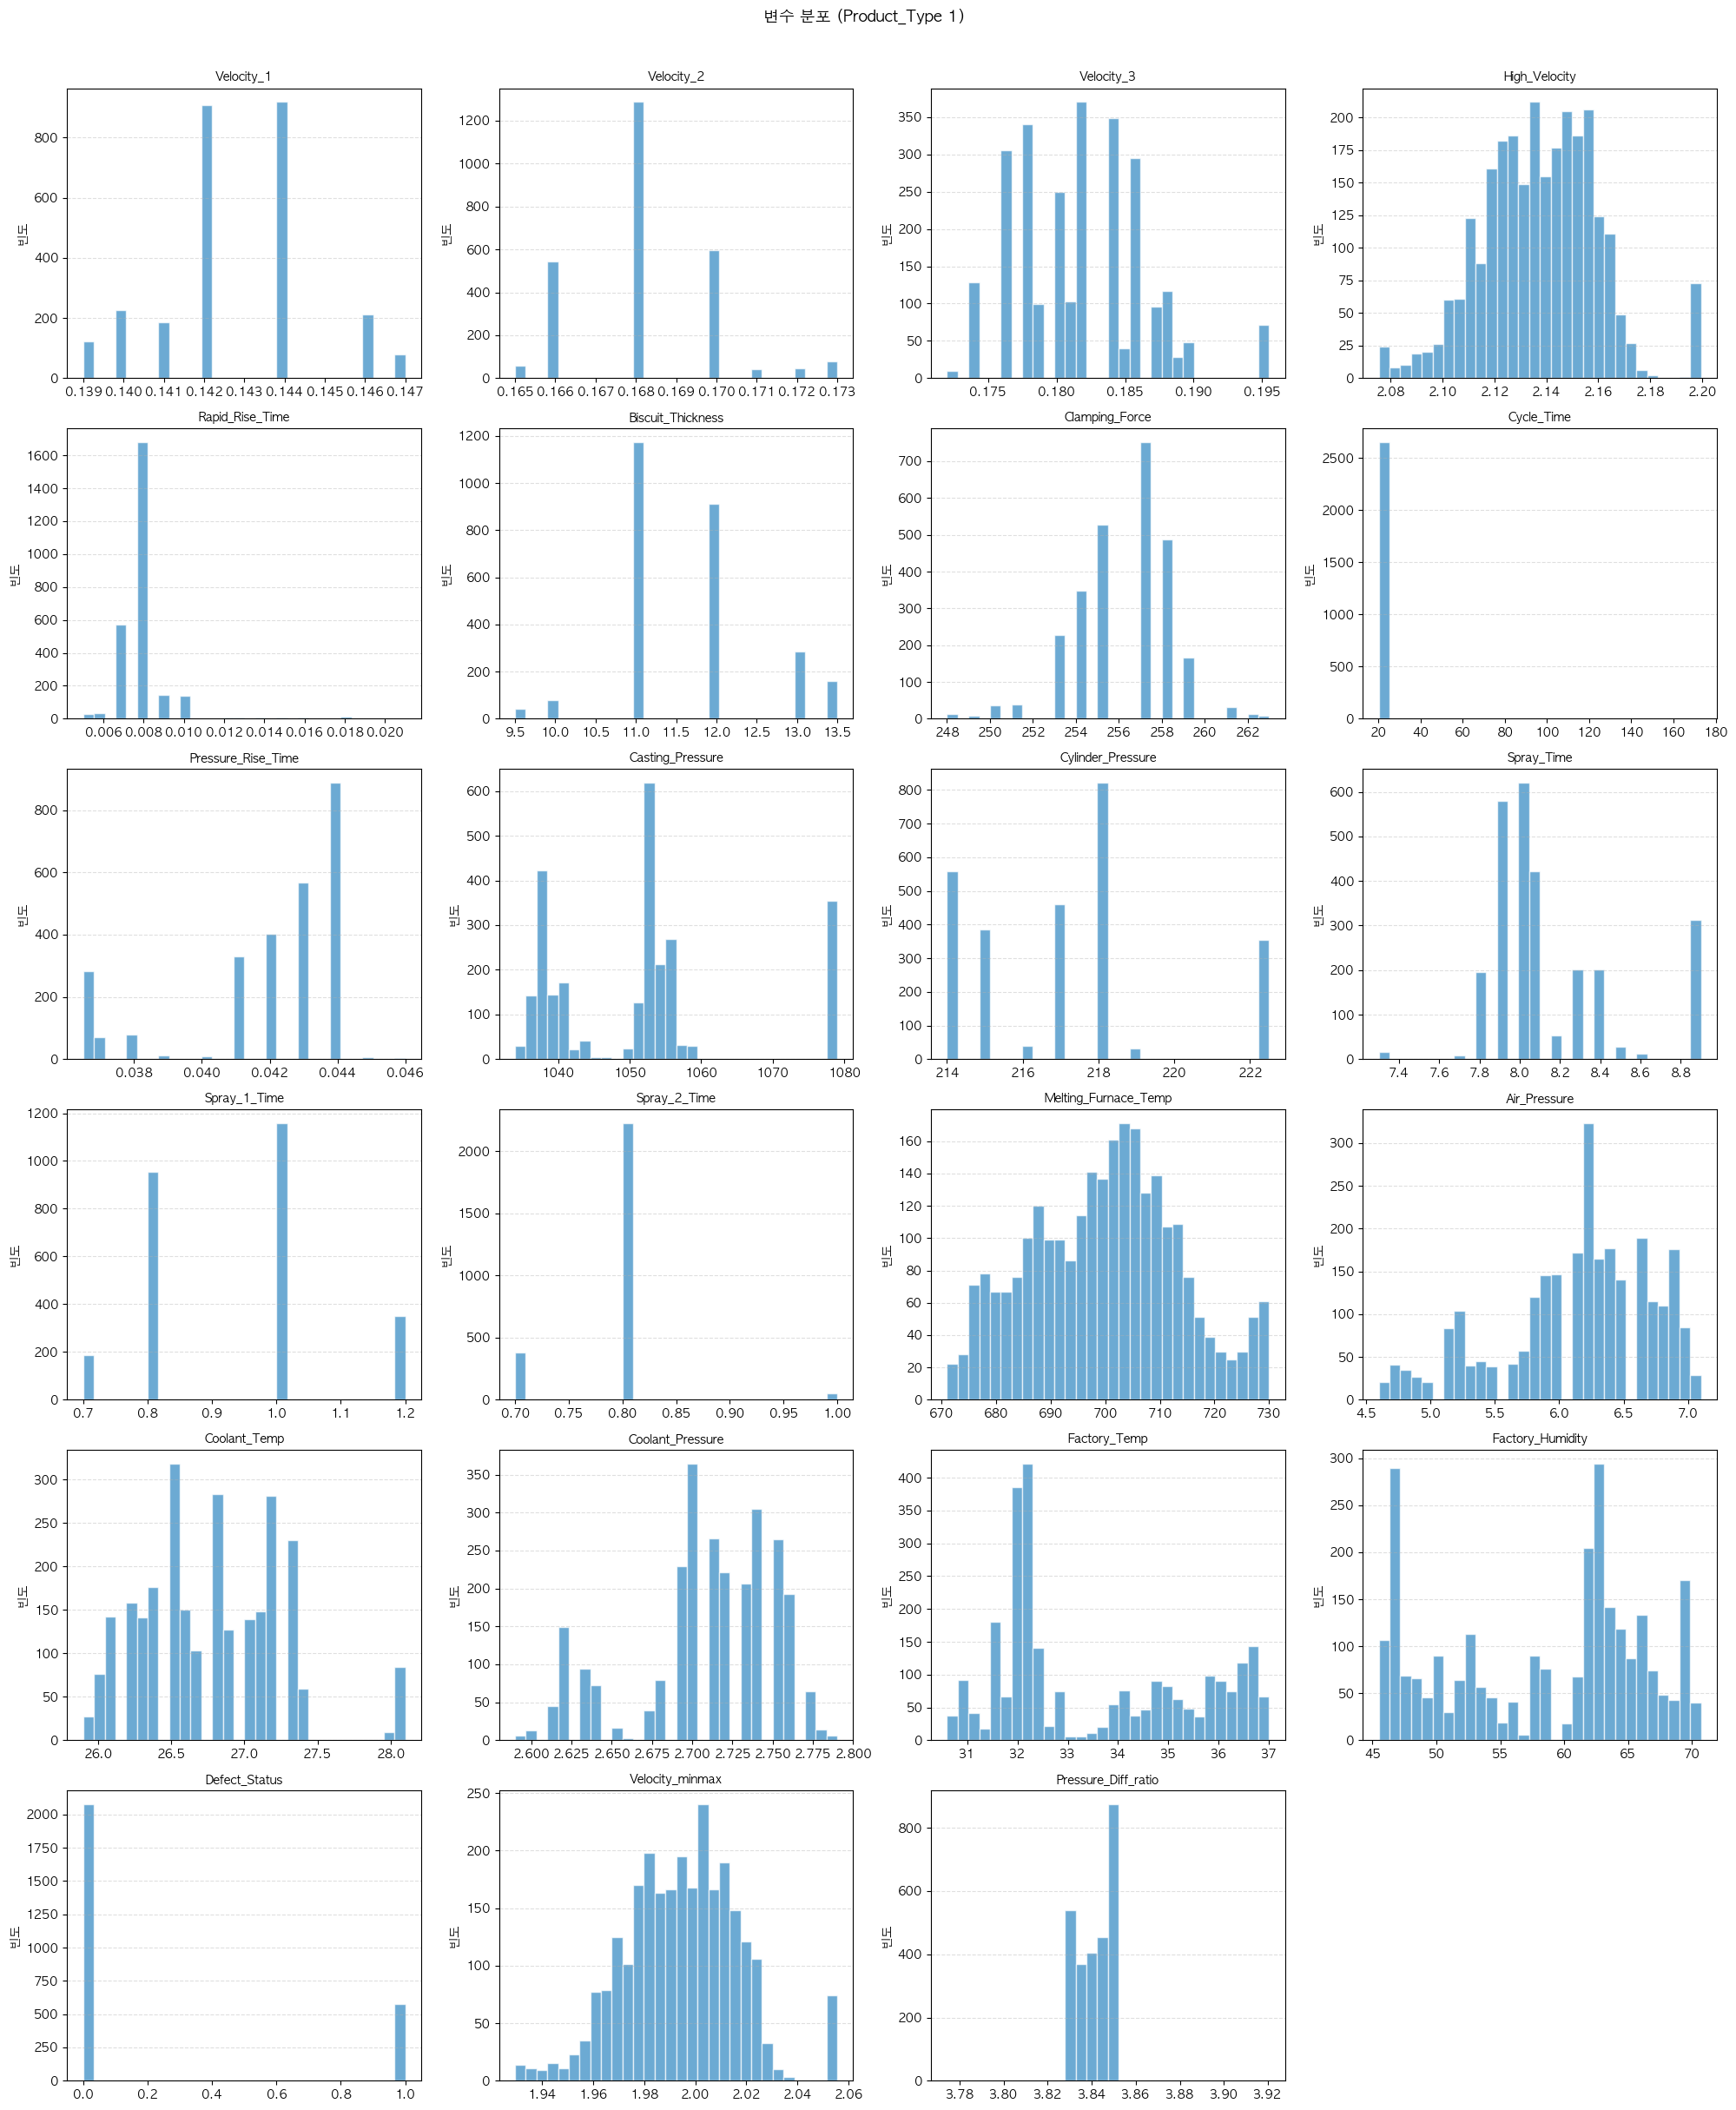

In [7]:
import math

final_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Casting_Pressure',
    'Cylinder_Pressure', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Defect_Status', 
    'Defect_Type', 
    'Velocity_minmax', 
    'Pressure_Diff_ratio'
]
# 변수 히스토그램
num_cols = [col for col in final_vars if type1_df[col].dtype in ['int64', 'float64']]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(type1_df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

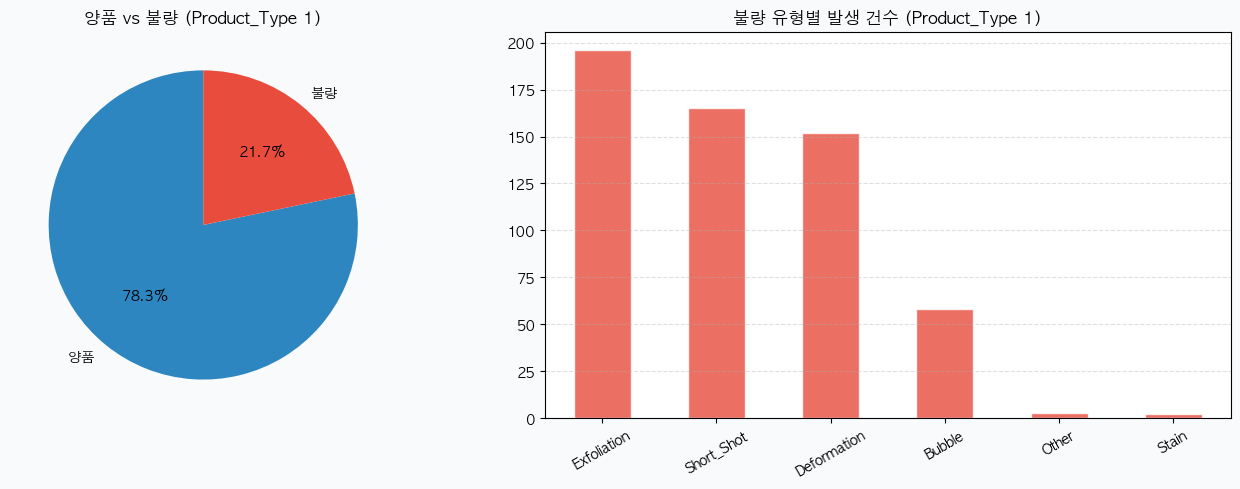

In [8]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = type1_df['Defect_Status'].value_counts().sort_index()
axes[0].pie(sizes, labels=['양품', '불량'], autopct='%1.1f%%',
            colors=['#2E86C1', '#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = type1_df[type1_df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import spearmanr

exclude_cols = ['Defect_Status', 'Defect_Type', 'id', 'Product_Type','Velocity_minmax', 'Velocity_diff_1_2',
       'Velocity_diff_2_3', 'Velocity_diff_3_high', 'Pressure_Diff','Casting_Pressure','Cylinder_Pressure'] 

results = []

for col in type1_df.columns:
    if col in exclude_cols:
        continue
    clean = type1_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
    })

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df.insert(0, 'rank', range(1, len(spearman_df)+1))
spearman_df = spearman_df.set_index("rank")
display(spearman_df)

,변수,스피어만 상관계수,p-value,절댓값
rank,,,,
1,Factory_Humidity,-0.2782,0.0000,0.2782
2,Factory_Temp,0.2155,0.0000,0.2155
3,Biscuit_Thickness,-0.1699,0.0000,0.1699
4,Spray_2_Time,0.1669,0.0000,0.1669
5,Cycle_Time,-0.1204,0.0000,0.1204
6,Pressure_Diff_ratio,-0.0992,0.0000,0.0992
7,Pressure_Rise_Time,0.0990,0.0000,0.0990
8,Spray_Time,-0.0963,0.0000,0.0963
9,Clamping_Force,0.0797,0.0000,0.0797


In [24]:
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Diff_ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(type1_df[high_corr_vars].corr().round(3))
print()
print("※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장")
print("  Pressure_Diff = Casting_Pressure - Cylinder_Pressure")
print("  → 두 압력의 차이가 실질적인 정보를 담고 있음")

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Diff_ratio
Casting_Pressure,1.000,0.992,0.260
Cylinder_Pressure,0.992,1.000,0.133
Pressure_Diff_ratio,0.260,0.133,1.000



※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장
  Pressure_Diff = Casting_Pressure - Cylinder_Pressure
  → 두 압력의 차이가 실질적인 정보를 담고 있음


In [30]:
top10 = spearman_df.head(10).copy()

print("🏆 TOP 10 변수 (상관계수 기준)")
print("-" * 50)

for idx, row in top10.iterrows():   # idx가 rank 인덱스
    direction = "▼ 불량 감소" if row['스피어만 상관계수'] < 0 else "▲ 불량 증가"
    print(f"  #{int(idx):2d}  {row['변수']:<25}  {row['스피어만 상관계수']:+.4f}  {direction}")

🏆 TOP 10 변수 (상관계수 기준)
--------------------------------------------------
  # 1  Factory_Humidity           -0.2782  ▼ 불량 감소
  # 2  Factory_Temp               +0.2155  ▲ 불량 증가
  # 3  Biscuit_Thickness          -0.1699  ▼ 불량 감소
  # 4  Spray_2_Time               +0.1669  ▲ 불량 증가
  # 5  Cycle_Time                 -0.1204  ▼ 불량 감소
  # 6  Pressure_Diff_ratio        -0.0992  ▼ 불량 감소
  # 7  Pressure_Rise_Time         +0.0990  ▲ 불량 증가
  # 8  Spray_Time                 -0.0963  ▼ 불량 감소
  # 9  Clamping_Force             +0.0797  ▲ 불량 증가
  #10  Melting_Furnace_Temp       -0.0770  ▼ 불량 감소


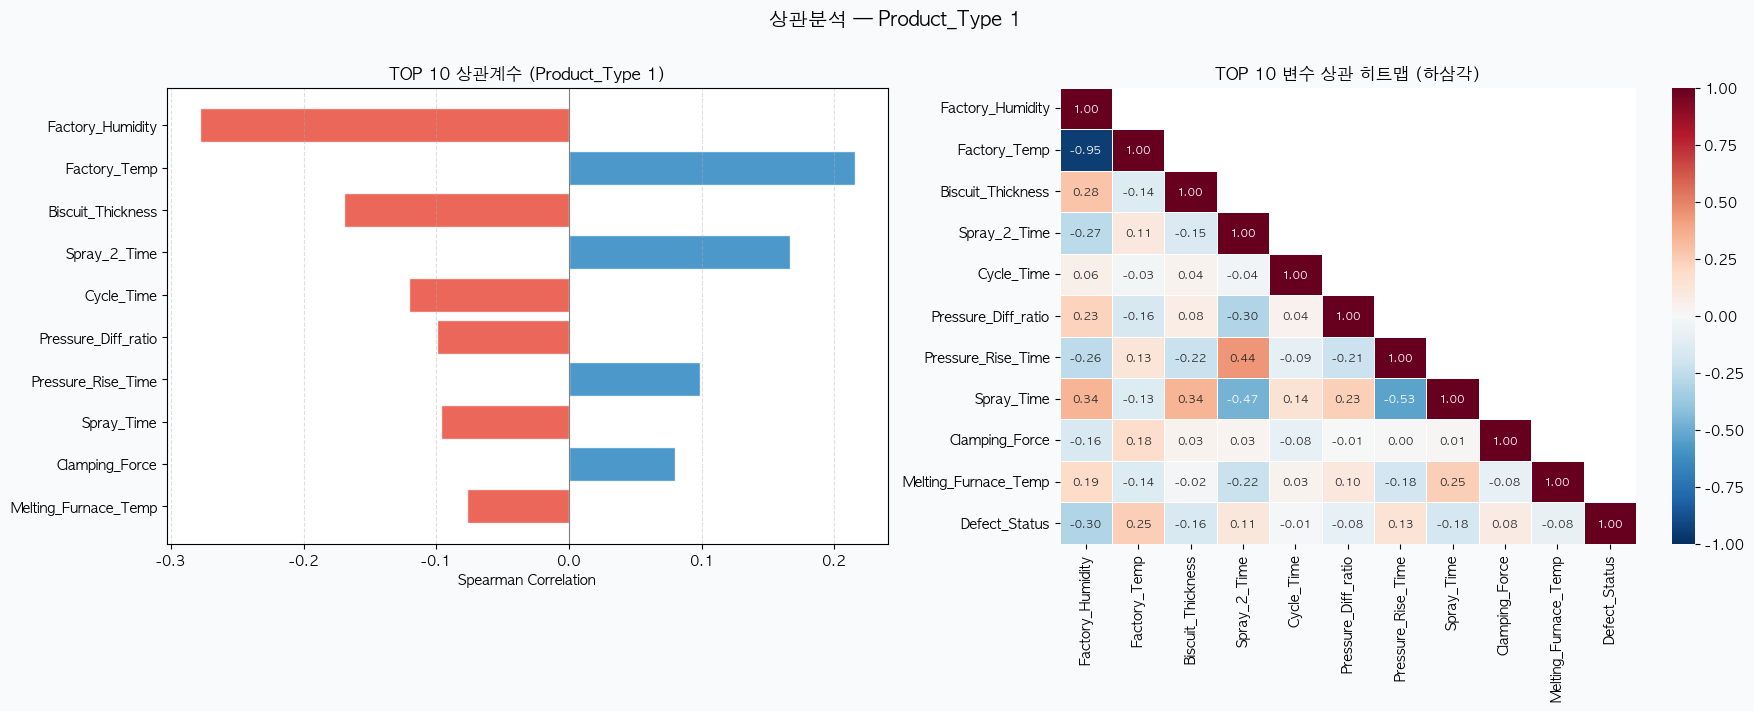

In [33]:
import numpy as np
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['스피어만 상관계수']]
axes[0].barh(top10['변수'][::-1], top10['스피어만 상관계수'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spearman Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# 히트맵
top10_vars = top10['변수'].tolist()
corr_matrix = type1_df[top10_vars + ['Defect_Status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
#---------------------
# 1. 정규성 검정
#---------------------
from scipy import stats

target_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Casting_Pressure',
    'Cylinder_Pressure',
    'Pressure_Diff_ratio'
]

results = []
for col in target_vars:
    stat, p = stats.shapiro(type1_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성
0,Velocity_1,0.9213,0.0,❌
1,Velocity_2,0.8756,0.0,❌
2,Velocity_3,0.9610,0.0,❌
3,High_Velocity,0.9834,0.0,❌
4,Rapid_Rise_Time,0.5515,0.0,❌
5,Biscuit_Thickness,0.8671,0.0,❌
6,Clamping_Force,0.9369,0.0,❌
7,Cycle_Time,0.0542,0.0,❌
8,Pressure_Rise_Time,0.7748,0.0,❌
9,Spray_Time,0.8200,0.0,❌


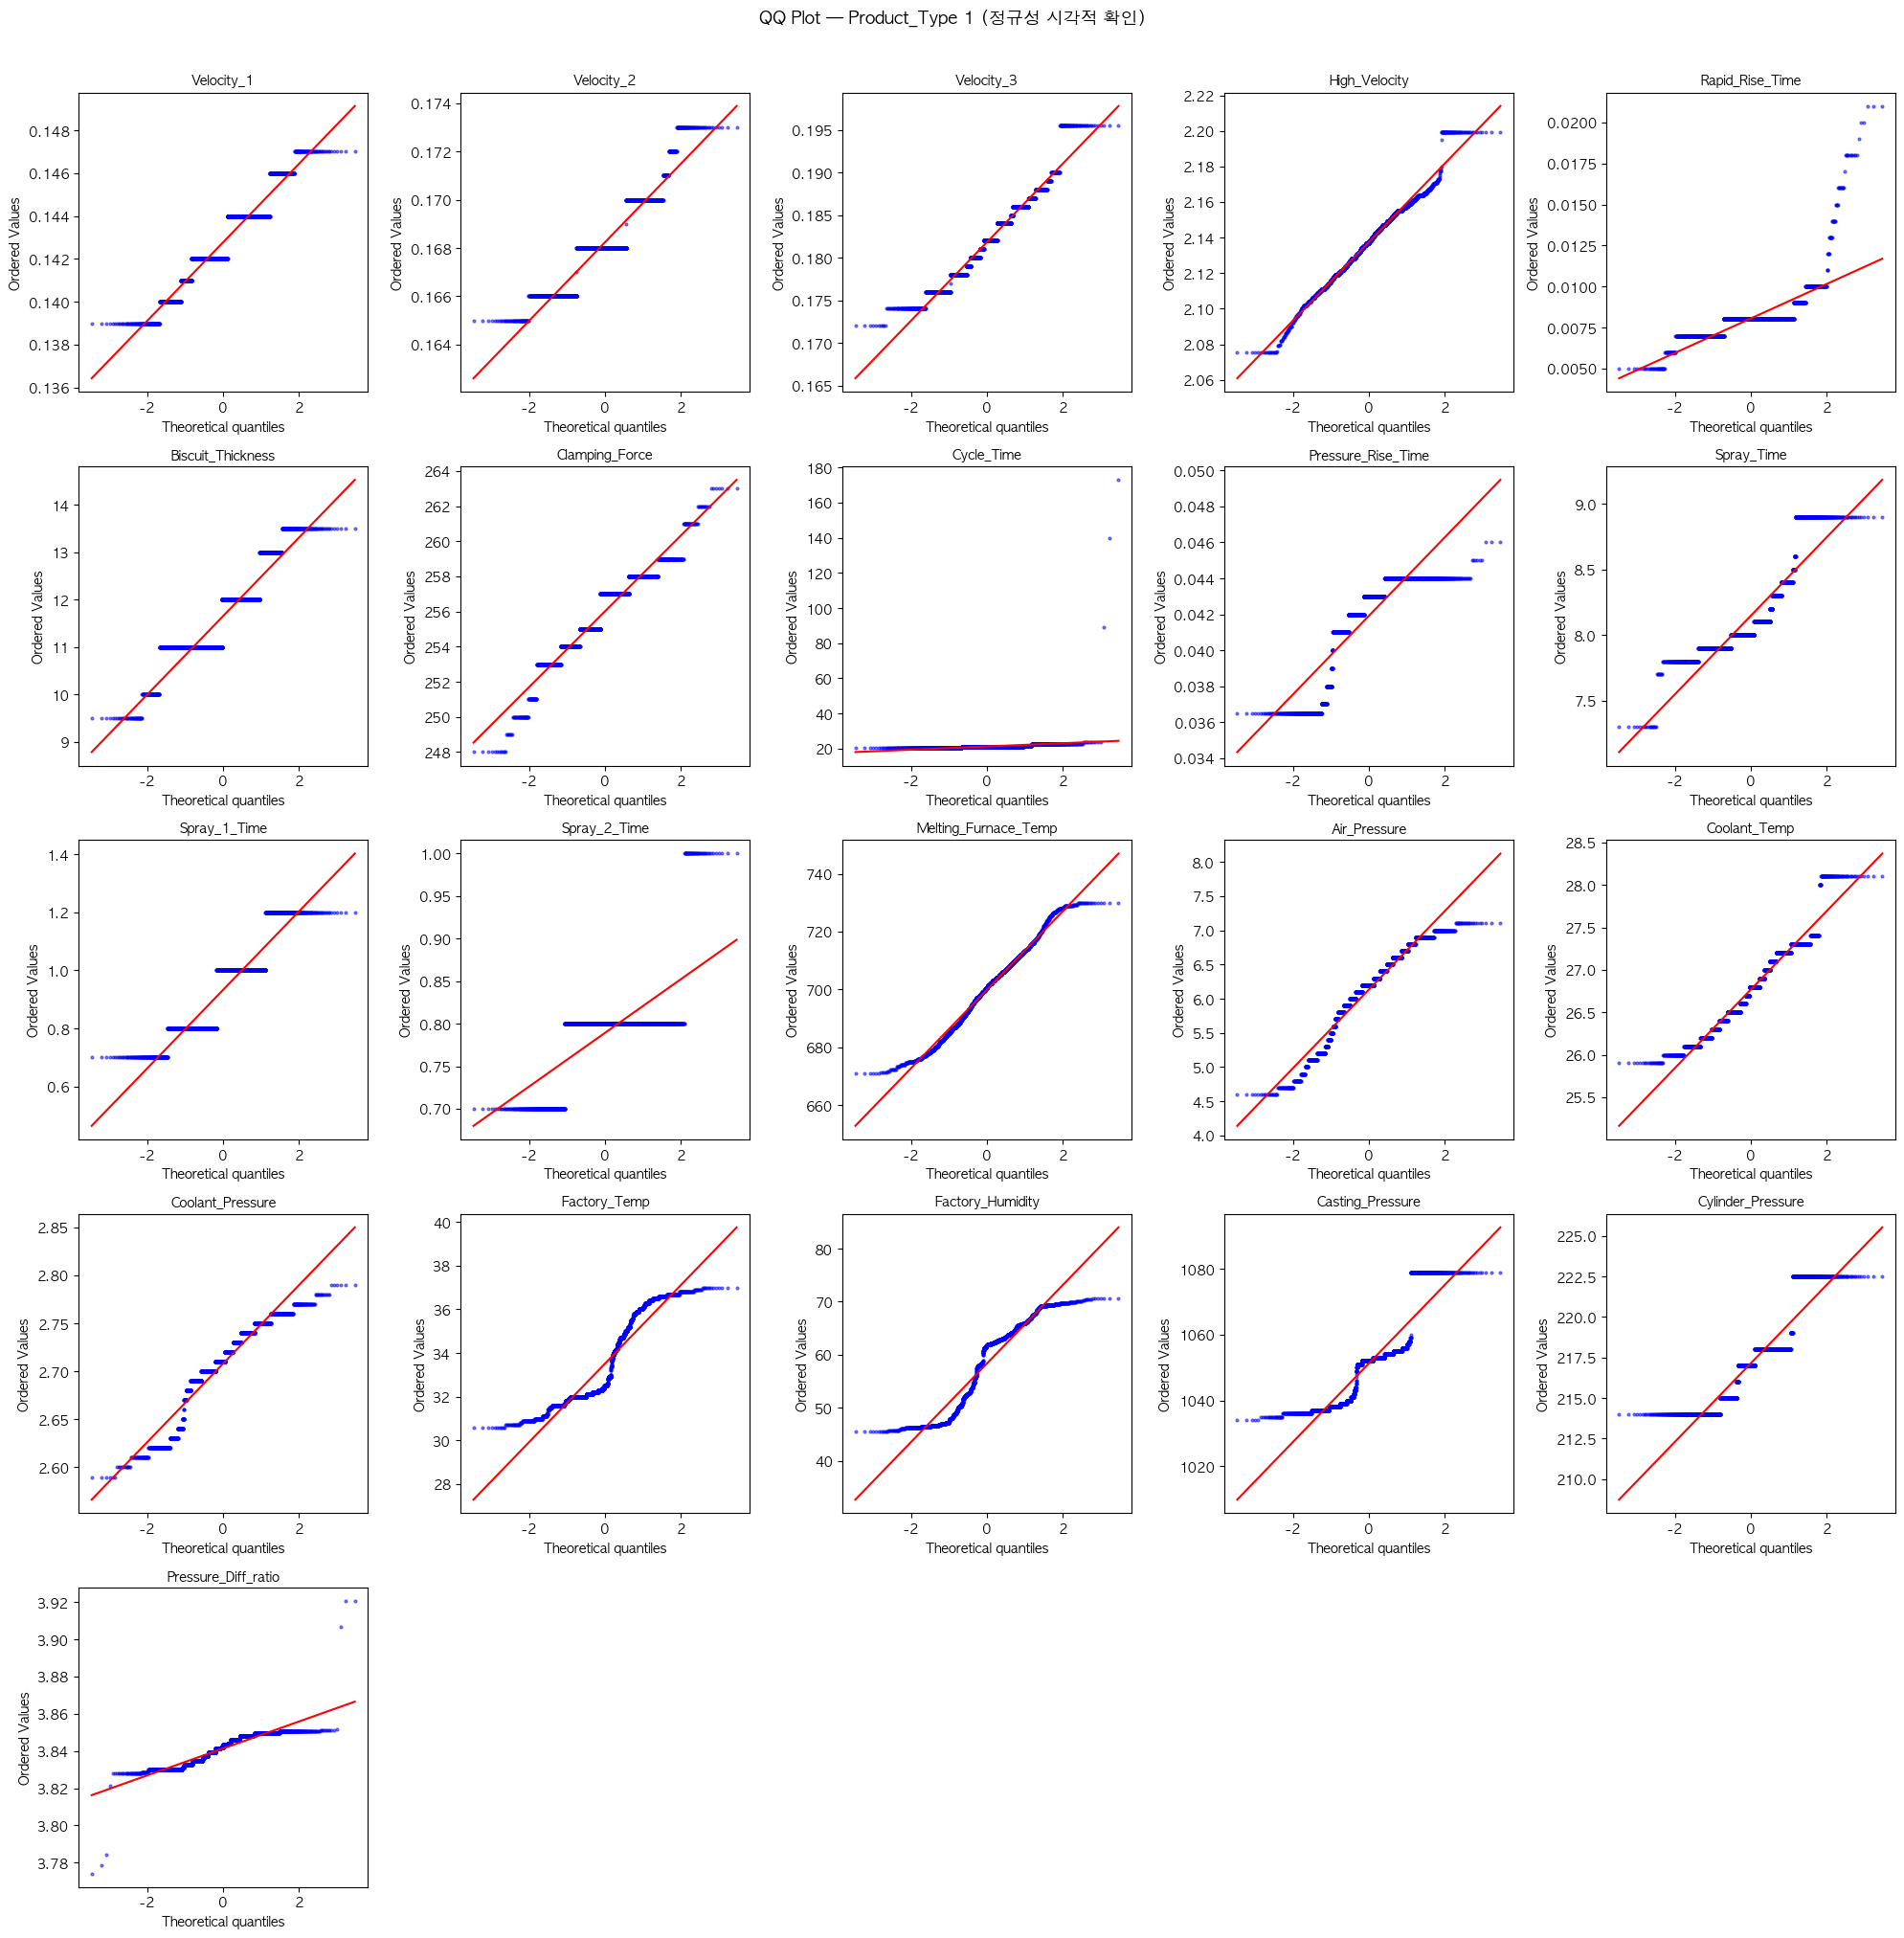

In [11]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(target_vars)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
#print(result_df.to_string(index=False))
display(pd.DataFrame(results))

,변수,U통계량,p-value,유의성
0,Velocity_1,616779.0,0.2178,❌
1,Velocity_2,565800.5,0.0355,✅
2,Velocity_3,575010.0,0.1622,❌
3,High_Velocity,658198.5,0.0002,✅
4,Rapid_Rise_Time,624281.5,0.0557,❌
5,Biscuit_Thickness,464880.0,0.0000,✅
6,Clamping_Force,662918.5,0.0000,✅
7,Cycle_Time,498077.5,0.0000,✅
8,Pressure_Rise_Time,678184.5,0.0000,✅
9,Spray_Time,518244.0,0.0000,✅


In [13]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(pd.DataFrame(results))

,변수,p-value,효과크기(r),해석
0,Velocity_1,0.2178,0.0321,소
1,Velocity_2,0.0355,0.0532,소
2,Velocity_3,0.1622,0.0378,소
3,High_Velocity,0.0002,0.1014,소
4,Rapid_Rise_Time,0.0557,0.0446,소
5,Biscuit_Thickness,0.0000,0.2221,소
6,Clamping_Force,0.0000,0.1093,소
7,Cycle_Time,0.0000,0.1665,소
8,Pressure_Rise_Time,0.0000,0.1348,소
9,Spray_Time,0.0000,0.1328,소


In [14]:
#-------------------------------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#-------------------------------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(pd.DataFrame(results))

,변수,H통계량,p-value,유의성
0,Velocity_1,5.81,0.2136,❌
1,Velocity_2,9.22,0.0558,❌
2,Velocity_3,5.54,0.2364,❌
3,High_Velocity,22.03,0.0002,✅
4,Rapid_Rise_Time,6.04,0.1963,❌
5,Biscuit_Thickness,76.29,0.0000,✅
6,Clamping_Force,20.38,0.0004,✅
7,Cycle_Time,44.95,0.0000,✅
8,Pressure_Rise_Time,29.81,0.0000,✅
9,Spray_Time,34.69,0.0000,✅


In [15]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal', 'Stain', 'Other']
n_total = len(type1_df)

target_vars_stat = [col for col in target_vars if col not in ['Defect_Status', 'Defect_Type']]

results = []
for col in target_vars_stat:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
display(result_df)

,변수,H통계량,p-value,ε²,해석
17,Factory_Humidity,276.71,0.0000,0.1044,중
16,Factory_Temp,224.09,0.0000,0.0846,중
5,Biscuit_Thickness,79.98,0.0000,0.0302,소
11,Spray_2_Time,74.29,0.0000,0.0280,소
14,Coolant_Temp,72.72,0.0000,0.0274,소
18,Casting_Pressure,47.78,0.0000,0.0180,소
15,Coolant_Pressure,45.85,0.0000,0.0173,소
7,Cycle_Time,45.68,0.0000,0.0172,소
19,Cylinder_Pressure,43.78,0.0000,0.0165,소
10,Spray_1_Time,38.46,0.0000,0.0145,소


In [16]:
#---------------------
# 6. 사후검정 (Dunn's Test)
#---------------------
from IPython.display import display
import scikit_posthocs as sp

defect_types_list = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Other', 'Stain', 'Normal']

final_vars_stat = [col for col in final_vars if col not in ['Defect_Status', 'Defect_Type']]

for col in final_vars_stat:
    print(f'\n--- {col} ---')
    
    dunn = sp.posthoc_dunn(
        type1_df[type1_df['Defect_Type'].isin(defect_types_list)],
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    
    display(dunn.round(4))


--- Velocity_1 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Deformation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Exfoliation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Other,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- Velocity_2 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,1.0,0.1502,1.0,0.9238,1.0
Exfoliation,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Normal,1.0,0.1502,1.0,1.0000,1.0,1.0000,1.0
Other,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,0.9238,1.0,1.0000,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0



--- Velocity_3 ---


...

,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0000,0.3889,0.0262,0.0,1.0,0.2759,1.0
Deformation,0.3889,1.0000,0.0000,0.0,1.0,0.0000,1.0
Exfoliation,0.0262,0.0000,1.0000,0.0,1.0,1.0000,1.0
Normal,0.0000,0.0000,0.0000,1.0,1.0,0.0000,1.0
Other,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0
Short_Shot,0.2759,0.0000,1.0000,0.0,1.0,1.0000,1.0
Stain,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0



--- Velocity_minmax ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,0.2465,0.0142,1.0,1.0000,1.0
Exfoliation,1.0,0.2465,1.0000,1.0000,1.0,0.4434,1.0
Normal,1.0,0.0142,1.0000,1.0000,1.0,0.0314,1.0
Other,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,1.0000,0.4434,0.0314,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0



--- Pressure_Diff_ratio ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,1.0000,0.0055,1.0,1.0000,1.0
Exfoliation,1.0,1.0000,1.0000,0.4135,1.0,1.0000,1.0
Normal,1.0,0.0055,0.4135,1.0000,1.0,0.0533,1.0
Other,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,1.0000,1.0000,0.0533,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
